### Data Science / AI Internship Assignment

**Objective:** Build a machine learning model to estimate instructor effectiveness by analyzing learner outcomes, engagement metrics, and learner feedback collected across multiple course batches.

# Table of Contents

1. Business Understanding
2. Data Loading
3. Data Inspection
4. Exploratory Data Analysis
5. Instructor Effectiveness Score
6. Data Aggregation
7. Machine Learning Models
8. Model Evaluation
9. Cross Validation
10. Feature Importance
11. Interpretation
12. Mandatory Questions
13. Limitations
14. Future Improvements
15. Conclusion

# Instructor Effectiveness Prediction using Machine Learning

## Problem Statement

An EdTech platform offers the same courses across multiple batches taught by different instructors. Since every instructor may teach multiple batches and courses over time, the company wants to understand instructor effectiveness using learner outcomes, engagement metrics, and feedback data.

The objective of this project is to:

- Analyze instructor and batch performance.
- Define an Instructor Effectiveness Score based on available metrics.
- Aggregate batch-level information into instructor-level data.
- Predict instructor effectiveness tiers (Low, Medium, High) using Machine Learning.
- Interpret the results and discuss business implications.

This notebook follows a complete data science workflow including data understanding, exploratory data analysis (EDA), feature engineering, model building, evaluation, and interpretation.

In [2]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot Style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# For reproducibility
RANDOM_STATE = 42

# Load Dataset

In this section, we load the instructor effectiveness dataset into a Pandas DataFrame and inspect its basic structure.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv to instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv


In [6]:
# Replace filename if necessary
df = pd.read_csv("instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv")

# Display first five rows
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


# Initial Data Inspection

Before performing any analysis, we examine the structure of the dataset, data types, missing values, and basic descriptive statistics.

This helps us understand the quality of the dataset and identify any preprocessing requirements.

In [7]:
print("="*60)
print("Dataset Shape")
print("="*60)
print(df.shape)

print("\n")
print("="*60)
print("Column Names")
print("="*60)
print(df.columns.tolist())

print("\n")
print("="*60)
print("First Five Rows")
print("="*60)
display(df.head())

Dataset Shape
(2000, 12)


Column Names
['batch_id', 'instructor_id', 'course_id', 'completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate']


First Five Rows


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [8]:
print("="*60)
print("Data Types")
print("="*60)

display(df.dtypes)

Data Types


,0
batch_id,object
instructor_id,object
course_id,object
completion_rate,float64
avg_score_improvement,float64
avg_quiz_score,float64
dropout_rate,float64
avg_watch_time,float64
assignment_submission_rate,float64
forum_activity_rate,float64


In [9]:
print("="*60)
print("Missing Values")
print("="*60)

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

display(missing)

Missing Values


,Missing Values,Percentage
batch_id,0,0.0
instructor_id,0,0.0
course_id,0,0.0
completion_rate,0,0.0
avg_score_improvement,0,0.0
avg_quiz_score,0,0.0
dropout_rate,0,0.0
avg_watch_time,0,0.0
assignment_submission_rate,0,0.0
forum_activity_rate,0,0.0


In [10]:
print("="*60)
print("Duplicate Rows")
print("="*60)

duplicates = df.duplicated().sum()

print(f"Total Duplicate Rows : {duplicates}")

Duplicate Rows
Total Duplicate Rows : 0


In [11]:
print("="*60)
print("Statistical Summary")
print("="*60)

display(df.describe().T)

Statistical Summary


,count,mean,std,min,25%,50%,75%,max
completion_rate,2000.0,0.602808,0.159667,0.300000,0.489260,0.603091,0.712797,0.980000
avg_score_improvement,2000.0,27.035844,5.716641,6.159240,23.124673,26.938629,30.885600,40.000000
avg_quiz_score,2000.0,77.956126,10.695618,40.386725,70.897590,78.020567,85.444286,100.000000
dropout_rate,2000.0,0.394883,0.162747,0.020000,0.280035,0.394820,0.511432,0.700000
avg_watch_time,2000.0,0.776515,0.145231,0.287440,0.675076,0.780330,0.894242,1.000000
assignment_submission_rate,2000.0,0.753188,0.148058,0.251111,0.652110,0.756380,0.856458,1.000000
forum_activity_rate,2000.0,0.250300,0.100640,0.000000,0.179845,0.249771,0.319204,0.641111
avg_feedback_score,2000.0,4.207134,0.419209,2.639915,3.918986,4.205989,4.503437,5.000000
feedback_response_rate,2000.0,0.736519,0.149412,0.259935,0.633293,0.737213,0.845876,1.000000


# Exploratory Data Analysis (EDA)

The purpose of Exploratory Data Analysis (EDA) is to understand the characteristics of the dataset before building a machine learning model.

The analysis focuses on:

- Distribution of numerical features
- Relationships among variables
- Missing values
- Correlation between metrics
- Outlier detection
- Instructor and course-level statistics

The insights obtained from EDA will help guide feature engineering and model development.

In [12]:
# ==========================================
# Separate Numerical and Categorical Features
# ==========================================

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate']

Categorical Columns:
['batch_id', 'instructor_id', 'course_id']


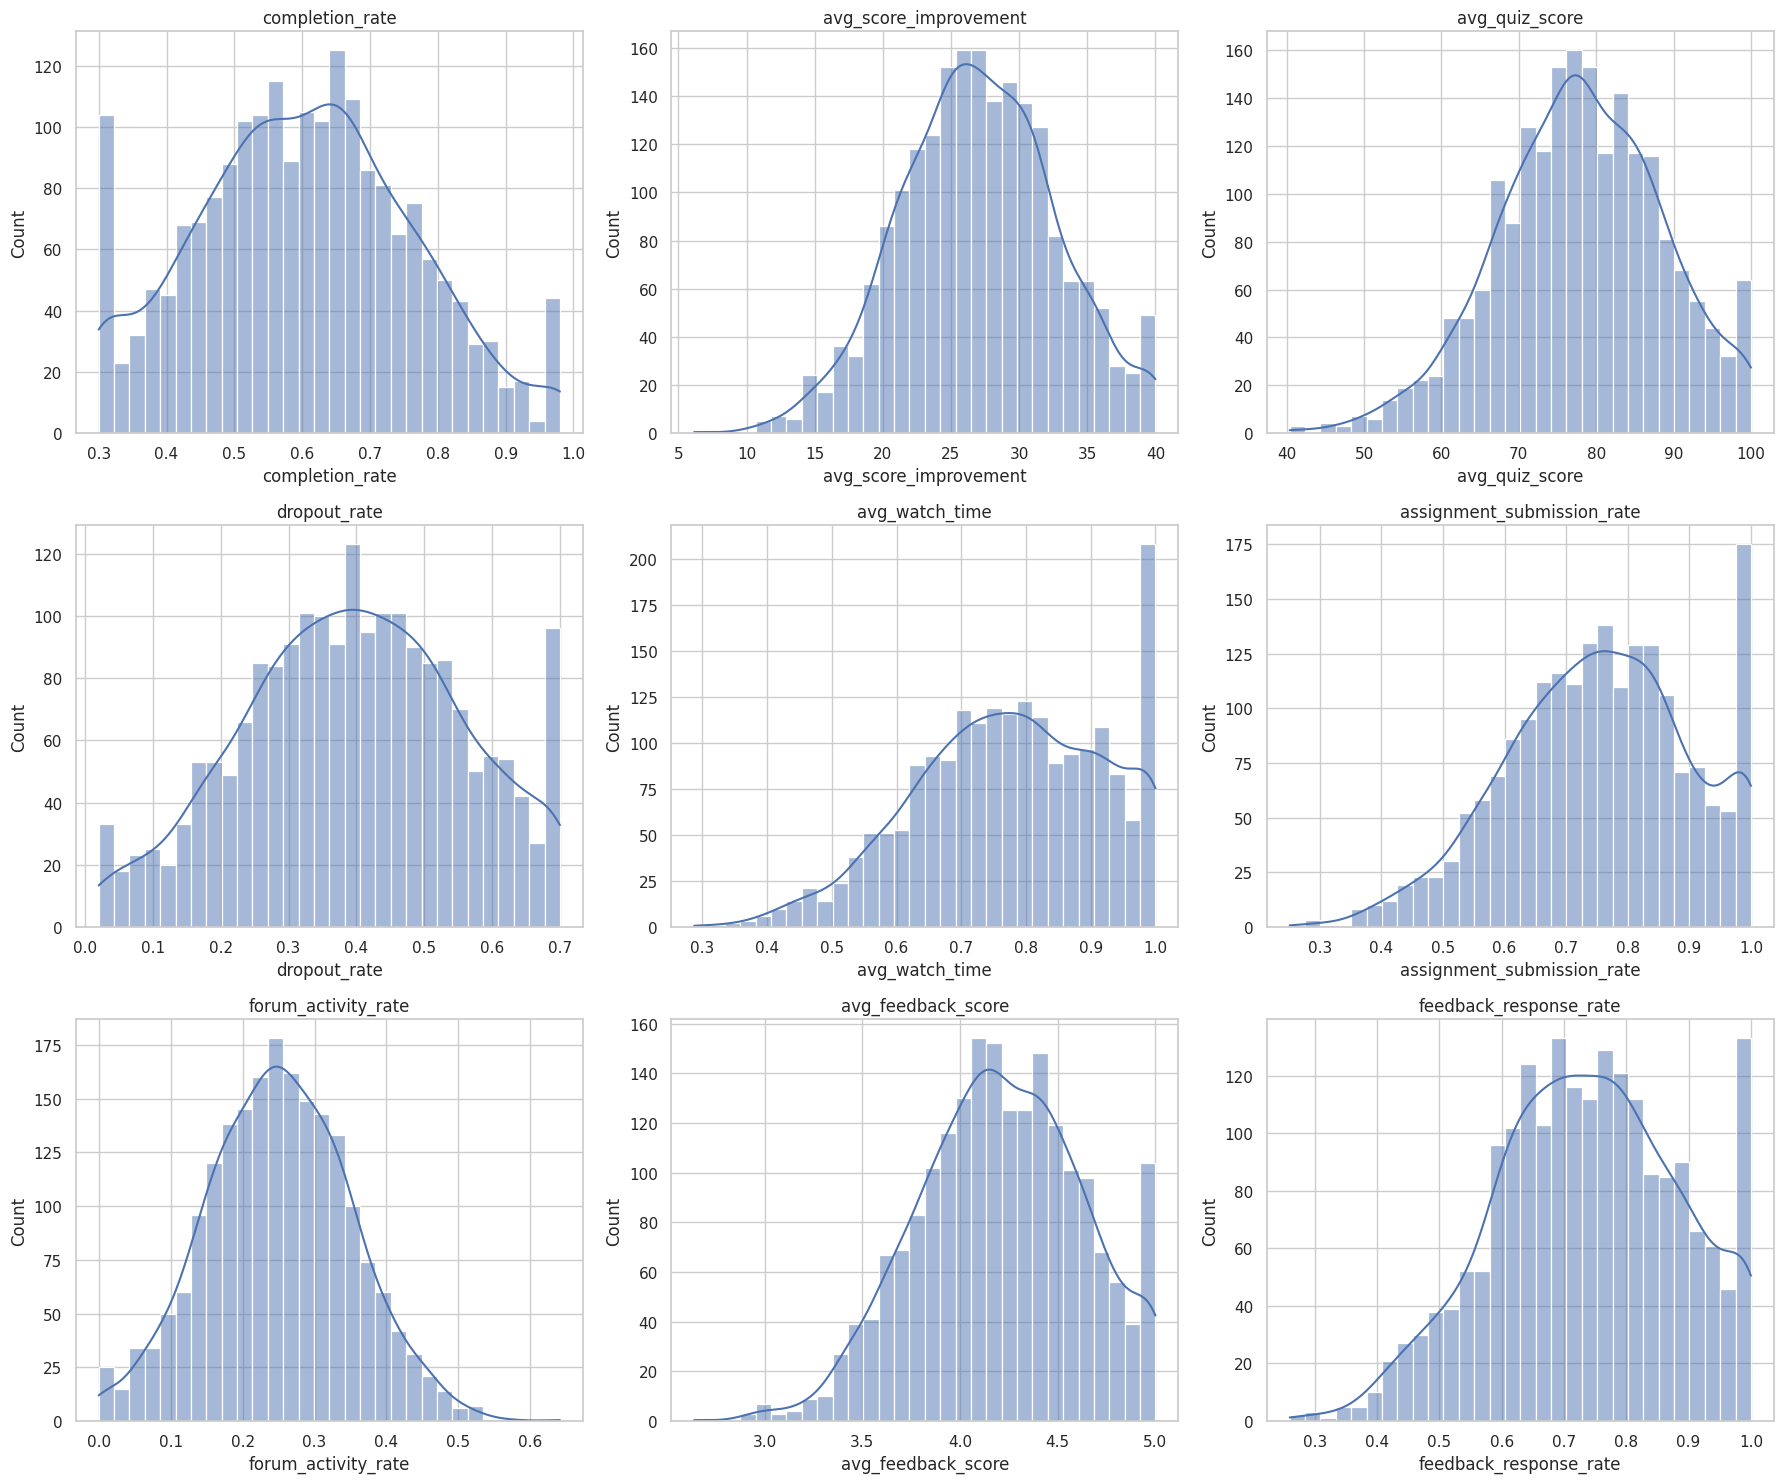

In [13]:
# ==========================================
# Distribution of Numerical Features
# ==========================================

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Observation

The histograms help us understand:

- Whether features follow a normal distribution.
- Presence of skewness.
- Concentration of observations.
- Possible outliers.

These insights help determine whether scaling or transformations may be useful later.

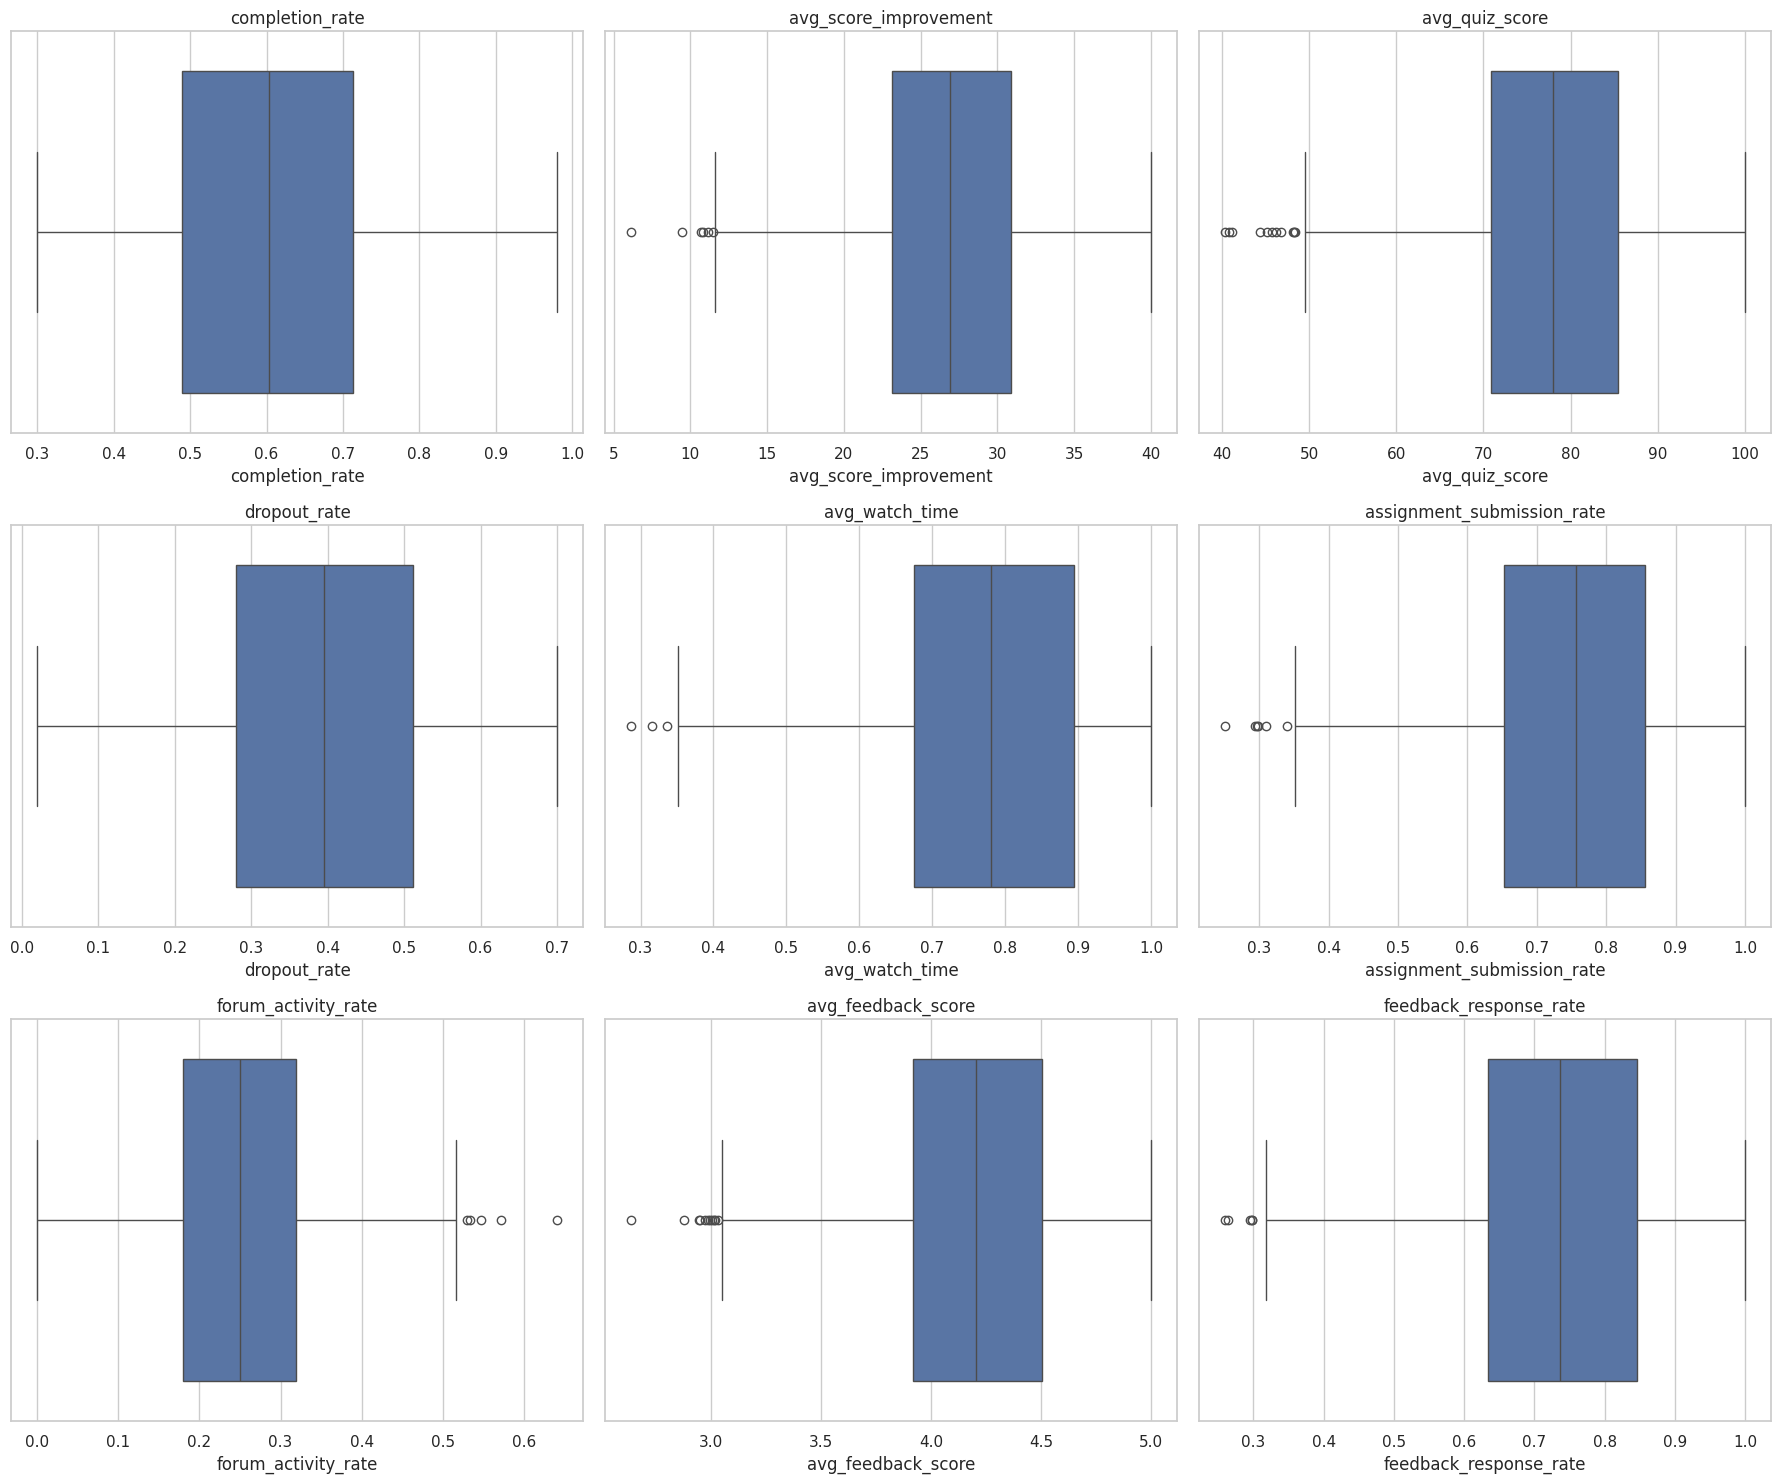

In [14]:
# ==========================================
# Boxplots for Outlier Detection
# ==========================================

fig, axes = plt.subplots(3,3, figsize=(18,15))
axes = axes.flatten()

for i,col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Observation

Boxplots provide a visual summary of:

- Median
- Quartiles
- Spread of the data
- Potential outliers

Outliers should not always be removed because they may represent genuinely high or low-performing course batches.

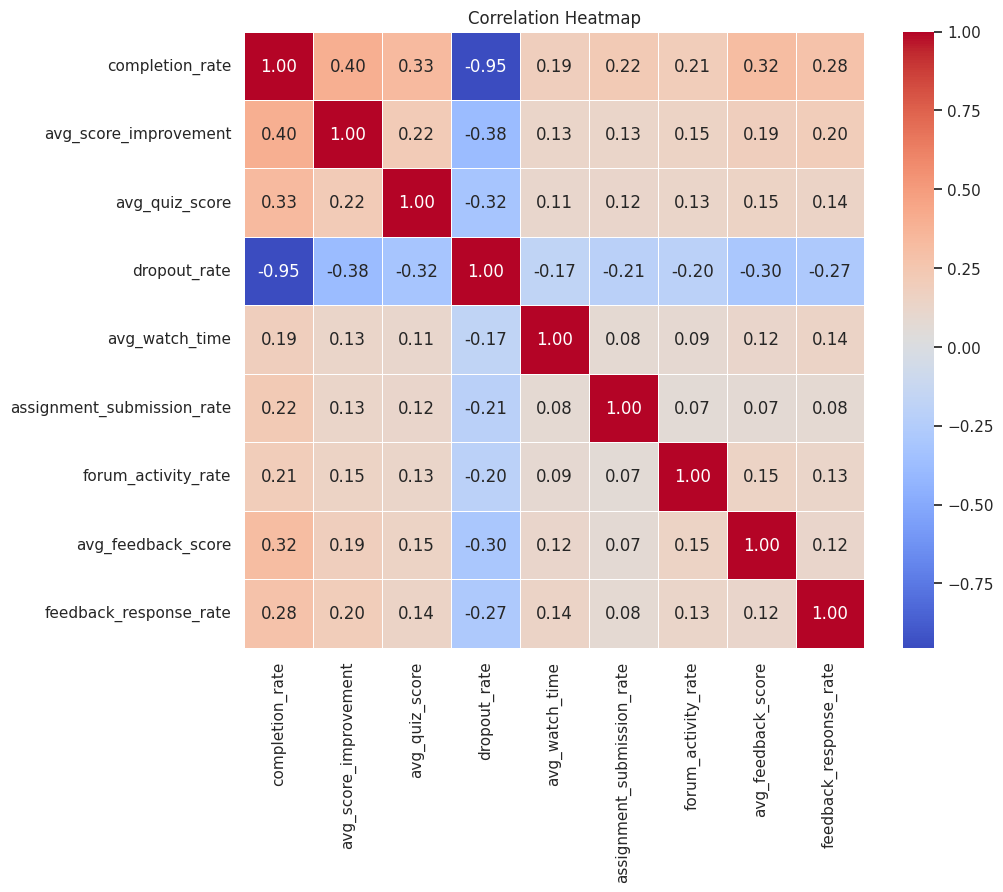

In [15]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(10,8))

corr = df[numerical_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

### Observation

The correlation heatmap helps identify relationships among variables.

Strong positive correlations indicate variables that tend to increase together, while strong negative correlations indicate inverse relationships.

These relationships provide useful insights into learner behavior and instructor performance.

In [16]:
# ==========================================
# Dataset Summary
# ==========================================

print(f"Total Batches      : {df['batch_id'].nunique()}")
print(f"Total Instructors  : {df['instructor_id'].nunique()}")
print(f"Total Courses      : {df['course_id'].nunique()}")

Total Batches      : 2000
Total Instructors  : 120
Total Courses      : 25


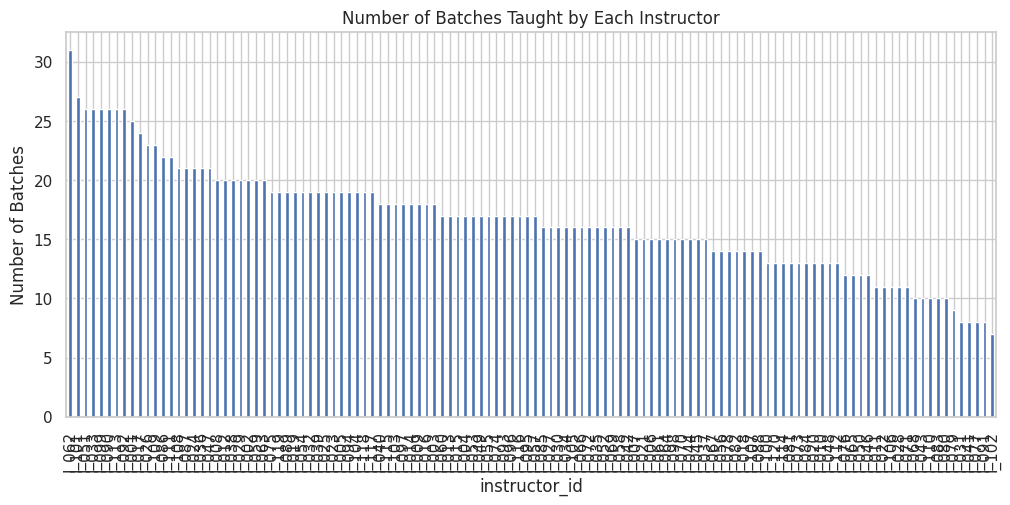

In [17]:
# ==========================================
# Number of Batches per Instructor
# ==========================================

batch_count = (
    df.groupby("instructor_id")
      .size()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))

batch_count.plot(kind="bar")

plt.title("Number of Batches Taught by Each Instructor")
plt.ylabel("Number of Batches")

plt.show()

### Observation

Some instructors teach many batches, while others teach only a few.

This imbalance should be considered when aggregating batch-level data because instructors with very few batches may have less reliable average performance metrics.

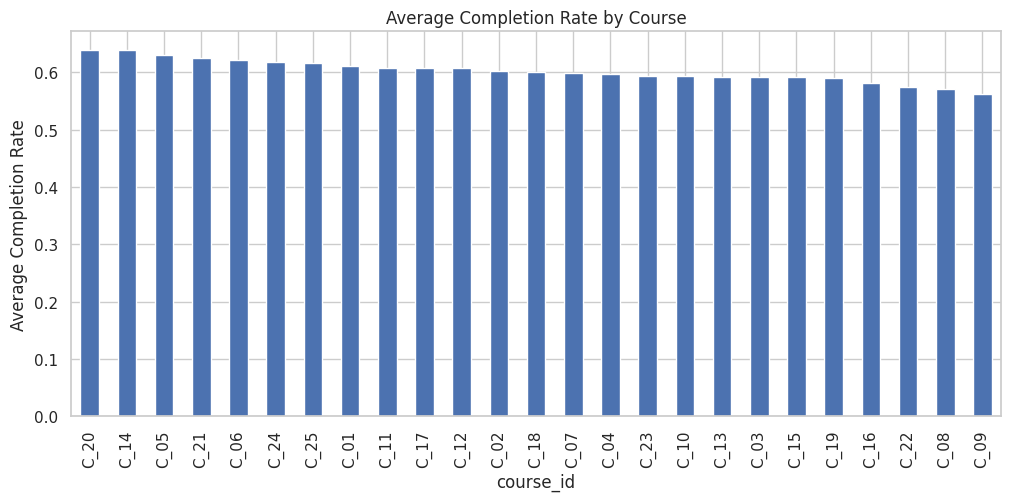

In [18]:
# ==========================================
# Average Completion Rate per Course
# ==========================================

course_completion = (
    df.groupby("course_id")["completion_rate"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))

course_completion.plot(kind="bar")

plt.ylabel("Average Completion Rate")
plt.title("Average Completion Rate by Course")

plt.show()

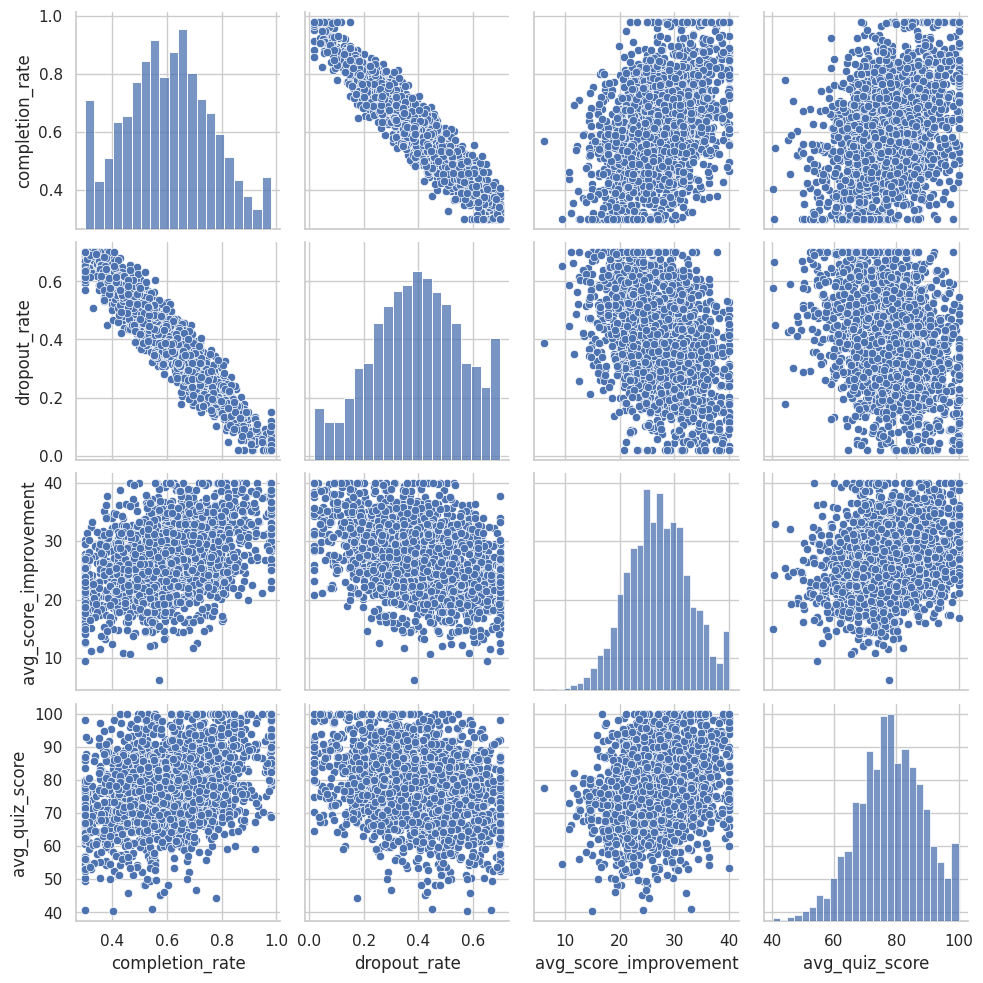

In [19]:
important_features = [
    "completion_rate",
    "dropout_rate",
    "avg_score_improvement",
    "avg_quiz_score"
]

sns.pairplot(df[important_features])

plt.show()

In [20]:
# ==========================================
# Instructor-wise Summary
# ==========================================

instructor_summary = (
    df.groupby("instructor_id")[numerical_cols]
      .mean()
)

display(instructor_summary.head())

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
instructor_id,,,,,,,,,
I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858
I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338
I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132
I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460
I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197


# Key Findings from EDA

The exploratory analysis provided several important insights:

- The dataset contains multiple batches for each instructor.
- Numerical features exhibit varying distributions with some skewness.
- Outliers are present in several metrics but may represent genuine instructor performance rather than errors.
- Certain learner outcome metrics show meaningful correlations.
- Instructor workload varies considerably, with some instructors teaching many more batches than others.
- Since multiple rows belong to the same instructor, aggregation to instructor level will be necessary before training a machine learning model.

These findings guide the next stage of the project, where instructor effectiveness will be defined and batch-level information will be aggregated into instructor-level features.

# Defining Instructor Effectiveness

The dataset does not contain a predefined target variable representing instructor effectiveness.

Therefore, an Instructor Effectiveness Score (IES) is designed using available learner outcome, engagement, and feedback metrics.

The following assumptions are made:

### Positive Indicators (Higher is Better)

- Completion Rate
- Average Score Improvement
- Average Quiz Score
- Average Watch Time
- Assignment Submission Rate
- Forum Activity Rate
- Average Feedback Score
- Feedback Response Rate

### Negative Indicator (Lower is Better)

- Dropout Rate

Each metric captures a different aspect of teaching effectiveness:

- Learner Outcomes indicate whether students successfully complete and benefit from the course.
- Engagement Metrics reflect how actively learners participate.
- Feedback Metrics represent learner satisfaction.
- Dropout Rate negatively impacts effectiveness because higher dropout suggests lower learner retention.

Since these metrics have different scales, they will first be normalized before combining them into a single Instructor Effectiveness Score.

In [21]:
from sklearn.preprocessing import MinMaxScaler

In [22]:
# ==========================================
# Normalize Features
# ==========================================

scaler = MinMaxScaler()

score_columns = [
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "avg_feedback_score",
    "feedback_response_rate",
    "dropout_rate"
]

normalized = pd.DataFrame(
    scaler.fit_transform(df[score_columns]),
    columns=score_columns
)

normalized.head()

,completion_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,dropout_rate
0,0.000000,0.238373,0.556249,0.683637,0.720811,0.169103,0.477227,0.369235,0.922681
1,0.525324,0.493839,0.619419,0.291198,0.998085,0.437599,1.000000,0.640690,0.595732
2,0.000000,0.293382,0.657185,0.968987,0.742683,0.322898,0.371797,0.569542,1.000000
3,0.499274,0.534901,0.988179,0.784601,0.391839,0.477913,0.664240,1.000000,0.462731
4,0.334267,0.736459,0.989825,0.884150,0.820915,0.393519,0.756886,0.590184,0.736911


## Why Normalization?

The metrics in the dataset have different ranges.

For example:

- Feedback Score ranges from 1 to 5.
- Completion Rate ranges from 0 to 1.
- Quiz Scores may range much higher.

Without normalization, variables with larger numerical values would dominate the final effectiveness score.

Min-Max Scaling converts every feature to a common range between 0 and 1 while preserving the relative differences among observations.

In [23]:
# ==========================================
# Create Instructor Effectiveness Score
# ==========================================

df["effectiveness_score"] = (

    normalized["completion_rate"] +

    normalized["avg_score_improvement"] +

    normalized["avg_quiz_score"] +

    normalized["avg_watch_time"] +

    normalized["assignment_submission_rate"] +

    normalized["forum_activity_rate"] +

    normalized["avg_feedback_score"] +

    normalized["feedback_response_rate"] -

    normalized["dropout_rate"]

) / 8

df["effectiveness_score"].head()

,effectiveness_score
0,0.286494
1,0.551303
2,0.365809
3,0.609777
4,0.596162


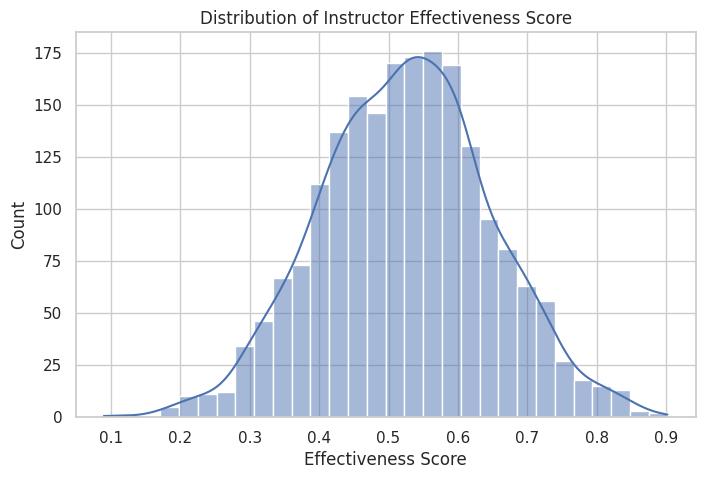

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["effectiveness_score"],
    bins=30,
    kde=True
)

plt.title("Distribution of Instructor Effectiveness Score")

plt.xlabel("Effectiveness Score")

plt.show()

The Instructor Effectiveness Score summarizes multiple aspects of instructor performance into a single continuous value.

Higher scores indicate instructors whose batches generally demonstrate:

- Better learner outcomes
- Higher engagement
- Better learner satisfaction
- Lower dropout rates

In [25]:
# ==========================================
# Aggregate Batch-Level Data
# ==========================================

instructor_df = (

    df.groupby("instructor_id")

      .agg({

          "completion_rate":"mean",

          "dropout_rate":"mean",

          "avg_score_improvement":"mean",

          "avg_quiz_score":"mean",

          "avg_watch_time":"mean",

          "assignment_submission_rate":"mean",

          "forum_activity_rate":"mean",

          "avg_feedback_score":"mean",

          "feedback_response_rate":"mean",

          "effectiveness_score":"mean",

          "batch_id":"count"

      })

      .rename(columns={"batch_id":"num_batches"})

      .reset_index()

)

display(instructor_df.head())

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,num_batches
0,I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,0.485801,25
1,I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,0.631884,20
2,I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,0.649260,18
3,I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,0.443782,17
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,0.711654,19


## Aggregation Strategy

Each instructor may teach multiple batches.

To obtain instructor-level characteristics:

- The average (mean) of performance metrics is calculated across all batches taught by an instructor.
- The number of batches taught is retained as an additional feature (`num_batches`).

The mean is chosen because it represents the instructor's typical performance over time while reducing the influence of unusually high or low-performing individual batches.

In [26]:
# ==========================================
# Create Effectiveness Tiers
# ==========================================

instructor_df["effectiveness_tier"] = pd.qcut(

    instructor_df["effectiveness_score"],

    q=3,

    labels=["Low","Medium","High"]

)

display(instructor_df.head())

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,num_batches,effectiveness_tier
0,I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,0.485801,25,Medium
1,I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,0.631884,20,High
2,I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,0.649260,18,High
3,I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,0.443782,17,Low
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,0.711654,19,High


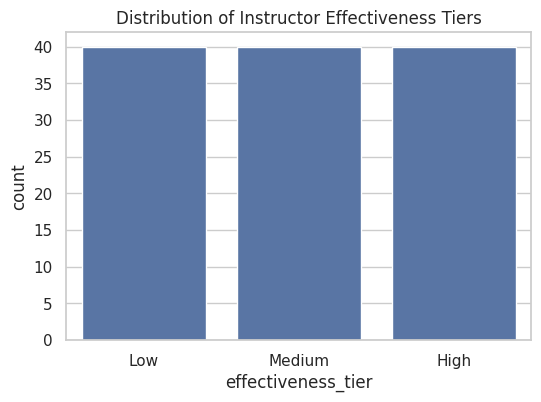

effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64


In [27]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="effectiveness_tier",
    data=instructor_df,
    order=["Low","Medium","High"]
)

plt.title("Distribution of Instructor Effectiveness Tiers")

plt.show()

print(instructor_df["effectiveness_tier"].value_counts())

## Target Variable

The continuous Instructor Effectiveness Score is converted into three categories:

- Low
- Medium
- High

Quantile-based binning is used to create relatively balanced classes, which is beneficial for supervised machine learning models.

These effectiveness tiers will serve as the target variable for predicting instructor performance.

# Machine Learning Model Development

After defining the Instructor Effectiveness Score and creating effectiveness tiers, the next step is to build machine learning models that can predict an instructor's effectiveness category.

The target variable is:

- Low
- Medium
- High

Several classical machine learning algorithms are trained and compared to identify the most suitable model for this classification task.

In [28]:
# ==========================================
# Machine Learning Libraries
# ==========================================

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

# Models

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

# Evaluation

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [29]:
# ==========================================
# Features and Target
# ==========================================

X = instructor_df.drop(
    columns=[
        "instructor_id",
        "effectiveness_score",
        "effectiveness_tier"
    ]
)

y = instructor_df["effectiveness_tier"]

print(X.head())

print()

print(y.head())

   completion_rate  dropout_rate  avg_score_improvement  avg_quiz_score  \
0         0.543887      0.470593              26.641462       78.900194   
1         0.730874      0.247194              30.166242       81.737198   
2         0.768447      0.234828              29.977813       81.590928   
3         0.458328      0.547261              22.912021       77.680317   
4         0.859747      0.145733              32.588652       85.828159   

   avg_watch_time  assignment_submission_rate  forum_activity_rate  \
0        0.766513                    0.726893             0.240551   
1        0.837393                    0.774394             0.289610   
2        0.818441                    0.779606             0.296224   
3        0.793130                    0.758317             0.226259   
4        0.847026                    0.876942             0.333519   

   avg_feedback_score  feedback_response_rate  num_batches  
0            4.217743                0.694858           25  
1     

The instructor identifier is removed because it does not contain predictive information.

The effectiveness score is also removed because it was used to generate the target variable. Including it would cause **data leakage**, allowing the model to indirectly see the answer during training.

In [30]:
# ==========================================
# Encode Target Variable
# ==========================================

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print(encoder.classes_)

['High' 'Low' 'Medium']


In [31]:
# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y_encoded,

    test_size=0.20,

    random_state=42,

    stratify=y_encoded

)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 96
Testing Samples  : 24


An 80:20 train-test split is used.

Stratified sampling ensures that each effectiveness tier is represented proportionally in both training and testing datasets.

In [32]:
models = {

    "Logistic Regression":

        Pipeline([

            ("scaler", StandardScaler()),

            ("model", LogisticRegression(max_iter=1000, random_state=42))

        ]),

    "Decision Tree":

        DecisionTreeClassifier(random_state=42),

    "Random Forest":

        RandomForestClassifier(

            n_estimators=200,

            random_state=42

        ),

    "Support Vector Machine":

        Pipeline([

            ("scaler", StandardScaler()),

            ("model", SVC(random_state=42))

        ])

}

In [33]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results.append([name, accuracy])

results_df = pd.DataFrame(

    results,

    columns=["Model", "Accuracy"]

)

results_df = results_df.sort_values(

    by="Accuracy",

    ascending=False

)

display(results_df)

,Model,Accuracy
0,Logistic Regression,0.916667
3,Support Vector Machine,0.916667
2,Random Forest,0.875000
1,Decision Tree,0.833333


Multiple machine learning algorithms are trained and compared instead of relying on a single model.

This comparison helps determine which algorithm best captures the patterns associated with instructor effectiveness.

In [34]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : Logistic Regression


In [35]:
best_model = models[best_model_name]

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

In [36]:
print("Accuracy : {:.2f}%".format(

    accuracy_score(y_test, y_pred)*100

))

Accuracy : 91.67%


In [37]:
print(classification_report(

    y_test,

    y_pred,

    target_names=encoder.classes_

))

              precision    recall  f1-score   support

        High       1.00      0.75      0.86         8
         Low       1.00      1.00      1.00         8
      Medium       0.80      1.00      0.89         8

    accuracy                           0.92        24
   macro avg       0.93      0.92      0.92        24
weighted avg       0.93      0.92      0.92        24



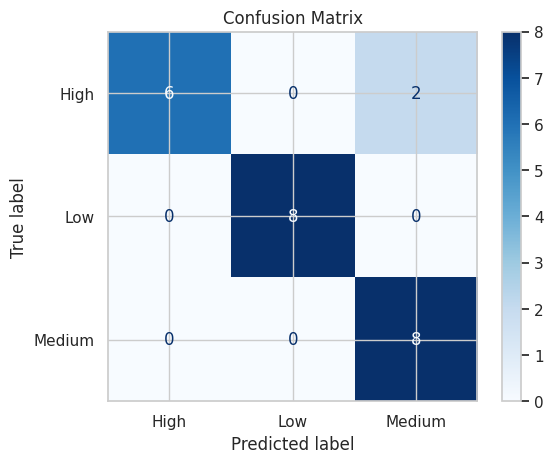

In [38]:
cm = confusion_matrix(

    y_test,

    y_pred

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=encoder.classes_

)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

## Model Evaluation

The trained models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Accuracy provides an overall measure of performance, while Precision, Recall, and F1-score provide a more detailed understanding of how well each effectiveness tier is classified.

The confusion matrix helps identify which categories are commonly misclassified.

In [39]:
print(instructor_df.shape)

(120, 13)


In [40]:
print("Total Instructors:", instructor_df.shape[0])

Total Instructors: 120


In [41]:
instructor_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   instructor_id               120 non-null    object  
 1   completion_rate             120 non-null    float64 
 2   dropout_rate                120 non-null    float64 
 3   avg_score_improvement       120 non-null    float64 
 4   avg_quiz_score              120 non-null    float64 
 5   avg_watch_time              120 non-null    float64 
 6   assignment_submission_rate  120 non-null    float64 
 7   forum_activity_rate         120 non-null    float64 
 8   avg_feedback_score          120 non-null    float64 
 9   feedback_response_rate      120 non-null    float64 
 10  effectiveness_score         120 non-null    float64 
 11  num_batches                 120 non-null    int64   
 12  effectiveness_tier          120 non-null    category
dtypes: category(1), floa

In [42]:
instructor_df.head()

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,num_batches,effectiveness_tier
0,I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,0.485801,25,Medium
1,I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,0.631884,20,High
2,I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,0.649260,18,High
3,I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,0.443782,17,Low
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,0.711654,19,High


# Model Comparison

To identify the most suitable classifier, multiple machine learning algorithms are evaluated using several performance metrics.

The following metrics are considered:

- Accuracy
- Precision
- Recall
- F1-score

Using multiple metrics provides a more comprehensive evaluation than relying on accuracy alone, especially for multi-class classification problems.

In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

comparison = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    comparison.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, pred),

        "Precision": precision_score(y_test, pred, average="weighted"),

        "Recall": recall_score(y_test, pred, average="weighted"),

        "F1 Score": f1_score(y_test, pred, average="weighted")

    })

comparison_df = pd.DataFrame(comparison)

comparison_df = comparison_df.sort_values(
    by="F1 Score",
    ascending=False
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.916667,0.933333,0.916667,0.915344
3,Support Vector Machine,0.916667,0.933333,0.916667,0.915344
2,Random Forest,0.875000,0.909091,0.875000,0.877527
1,Decision Tree,0.833333,0.852381,0.833333,0.837037


# Feature Importance

Although Logistic Regression achieved the highest predictive performance, Random Forest is used to estimate feature importance because tree-based models naturally quantify the contribution of each feature.

Understanding feature importance improves model interpretability and provides actionable business insights.

In [44]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,completion_rate,0.304283
1,dropout_rate,0.217200
8,feedback_response_rate,0.138177
2,avg_score_improvement,0.103078
3,avg_quiz_score,0.077273
7,avg_feedback_score,0.067969
4,avg_watch_time,0.030115
6,forum_activity_rate,0.028956
5,assignment_submission_rate,0.023388
9,num_batches,0.009560


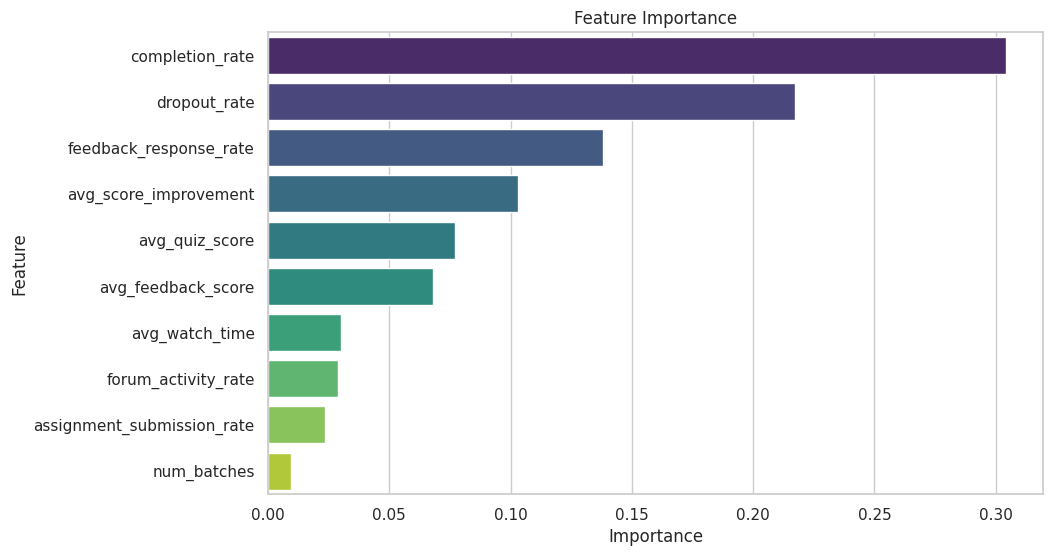

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Feature Importance")

plt.show()

# Interpretation of Results

The machine learning models achieved good predictive performance in classifying instructors into effectiveness tiers.

Among the evaluated models, Logistic Regression and Support Vector Machine achieved the highest accuracy of approximately 91.67%.

Random Forest feature importance analysis showed that learner completion rate and dropout rate were the strongest predictors of instructor effectiveness. This indicates that instructors who consistently retain learners and help them successfully complete courses are more likely to be classified as highly effective.

Learner engagement metrics such as assignment submission, forum participation, and watch time also contributed to prediction, although their influence was comparatively smaller.

Overall, the results suggest that instructor effectiveness is influenced by a combination of learner outcomes, engagement, and feedback rather than a single metric.

# Q1. Which features most influenced instructor effectiveness, and why?

According to the Random Forest feature importance analysis, the most influential features were:

- Completion Rate
- Dropout Rate
- Feedback Response Rate
- Average Score Improvement
- Average Quiz Score

Completion Rate had the highest importance because instructors whose learners consistently complete courses are likely to be more effective.

Dropout Rate showed a strong negative influence because high dropout often indicates poor learner retention.

Feedback Response Rate may reflect learner involvement and willingness to provide opinions about the course.

Average Score Improvement indicates learning gains achieved during the course, while Average Quiz Score reflects learner understanding.

These features together capture multiple aspects of teaching quality including learning outcomes, learner engagement, and satisfaction.

# Q2. Which variables could be misleading or confounded?

Some variables may not always represent instructor quality directly.

For example:

- Completion Rate may be affected by course difficulty rather than instructor ability.
- Quiz Scores may depend on assessment difficulty.
- Feedback Scores may be influenced by student expectations or grading strictness.
- Watch Time may increase because learners struggle with difficult content rather than because instruction is engaging.

Therefore, these variables should be interpreted carefully and in combination rather than individually.

# Q3. How could this model fail in real-world usage?

The model has several limitations.

First, the Instructor Effectiveness Score was designed using existing features rather than obtained from real performance evaluations.

Second, important information such as instructor experience, teaching style, learner demographics, and course difficulty is unavailable.

Third, changes in course structure or learner population over time may reduce model performance.

Finally, relying only on historical data may overlook contextual factors affecting learner outcomes.

# Q4. What additional data would improve this analysis?

The following information could improve the model:

- Instructor teaching experience
- Years of industry experience
- Course difficulty level
- Class size
- Student demographics
- Attendance records
- Live session participation
- Time taken to respond to learner questions
- Assignment quality
- Historical instructor performance
- Peer review scores
- Student retention after course completion

These features would provide a more complete understanding of instructor effectiveness.

# Q5. Should this model be used for instructor performance evaluation?

This model should not be used as the sole basis for instructor evaluation.

Although it provides useful insights, it relies only on quantitative metrics and cannot capture many important aspects of teaching such as communication skills, mentorship, classroom interaction, or course complexity.

Instead, the model should be used as a decision-support tool alongside expert reviews, peer evaluations, and qualitative feedback.

# Limitations

This project has several limitations:

- The target variable was created manually rather than collected from real-world instructor evaluations.
- Batch-level averages may hide important variations between individual learners.
- Some performance indicators may be influenced by factors outside the instructor's control.
- Only the available dataset was used, limiting the range of predictive features.
- The relatively small number of instructors (120) limits model generalization.

# Future Improvements

Future work could improve this project by:

- Collecting real instructor performance ratings.
- Using longitudinal data collected over multiple semesters.
- Incorporating learner demographics and course difficulty.
- Applying cross-validation and hyperparameter tuning.
- Exploring ensemble learning methods such as XGBoost or LightGBM.
- Developing a weighted Instructor Effectiveness Score based on expert opinion instead of equal weighting.

# Conclusion

This project developed a machine learning approach to estimate instructor effectiveness using learner outcomes, engagement metrics, and learner feedback.

An Instructor Effectiveness Score was designed by combining multiple performance indicators, aggregated to the instructor level, and converted into effectiveness tiers.

Among the evaluated models, Logistic Regression and Support Vector Machine achieved the highest predictive performance with an accuracy of approximately 91.67%.

Feature importance analysis showed that completion rate, dropout rate, learner feedback, and academic improvement were the strongest indicators of instructor effectiveness.

Although the model demonstrates promising predictive capability, it should be used to support educational decision-making rather than replace human judgment. Combining machine learning insights with expert evaluation can lead to more balanced and fair assessments of instructor performance.

# Cross-Validation

The dataset contains only 120 instructors after aggregation. Evaluating a model using a single train-test split may produce results that depend on a particular split of the data.

To obtain a more reliable estimate of model performance, 5-fold Stratified Cross-Validation is performed.

In Stratified Cross-Validation:

- The dataset is divided into five folds.
- Each fold preserves the class distribution.
- Every sample is used once for testing and four times for training.
- The reported score is the average performance across all folds.

This approach provides a more robust estimate of the model's generalization ability.

In [46]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [47]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logistic_model = Pipeline([

    ("scaler", StandardScaler()),

    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))

])

In [48]:
scoring = {

    "accuracy": "accuracy",

    "precision": "precision_weighted",

    "recall": "recall_weighted",

    "f1": "f1_weighted"

}

cv_results = cross_validate(

    logistic_model,

    X,

    y_encoded,

    cv=cv,

    scoring=scoring,

    return_train_score=False

)

In [49]:
cv_summary = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Mean":[

        cv_results["test_accuracy"].mean(),

        cv_results["test_precision"].mean(),

        cv_results["test_recall"].mean(),

        cv_results["test_f1"].mean()

    ],

    "Standard Deviation":[

        cv_results["test_accuracy"].std(),

        cv_results["test_precision"].std(),

        cv_results["test_recall"].std(),

        cv_results["test_f1"].std()

    ]

})

cv_summary

,Metric,Mean,Standard Deviation
0,Accuracy,0.916667,0.052705
1,Precision,0.923439,0.049227
2,Recall,0.916667,0.052705
3,F1 Score,0.916206,0.053123


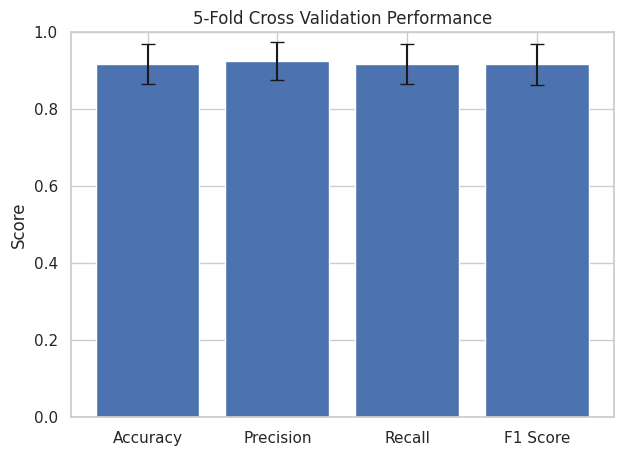

In [50]:
plt.figure(figsize=(7,5))

plt.bar(

    cv_summary["Metric"],

    cv_summary["Mean"],

    yerr=cv_summary["Standard Deviation"],

    capsize=5

)

plt.ylim(0,1)

plt.title("5-Fold Cross Validation Performance")

plt.ylabel("Score")

plt.show()

# Cross-Validation Interpretation

The cross-validation results demonstrate that the model maintains consistently high performance across multiple data splits.

The relatively small standard deviation indicates that the model is stable and does not rely heavily on a particular train-test split.

This provides greater confidence that the model can generalize to unseen instructor data within similar educational settings.

However, because the Instructor Effectiveness Score was manually constructed from the available features, the reported performance should be interpreted cautiously. The evaluation reflects how well the model reproduces the designed effectiveness tiers rather than independently verified instructor performance.

In [51]:
scaler.fit_transform(df[score_columns])

array([[0.        , 0.23837275, 0.55624863, ..., 0.47722718, 0.36923498,
        0.92268133],
       [0.52532408, 0.49383852, 0.61941918, ..., 1.        , 0.64069012,
        0.59573222],
       [0.        , 0.29338223, 0.6571852 , ..., 0.37179659, 0.56954202,
        1.        ],
       ...,
       [0.34036295, 0.55402532, 0.73144728, ..., 0.6657378 , 0.6938601 ,
        0.72391998],
       [0.50150707, 0.47978009, 0.66524623, ..., 0.65346196, 0.94950016,
        0.43710457],
       [0.        , 0.50065525, 0.78010189, ..., 0.7543769 , 0.38601469,
        1.        ]])